In [12]:
import json, os, copy

import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
#json_root =
dir_repo = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/tools/"
dataset_name = "200k_live_face_dataset"
dir_att = os.path.join(dir_repo,f"dataset_assessor/results_att_fd3-1-0/{dataset_name}")
dir_att_2 = os.path.join(dir_repo,f"dataset_assessor/results_att_fd3-1-0-temp/{dataset_name}")

In [14]:
def merge_nested_dicts(*dicts, mode="add_new"):
    """
    Merge multiple nested dictionaries without modifying the originals.

    Modes:
      - "add_new": add new top-level and nested keys
      - "existing_only": only merge into top-level keys that exist in the base dict,
                         but allow adding new nested keys inside those top-level keys.
    """
    if len(dicts) < 2:
        raise ValueError("Need at least two dictionaries to merge.")
    base = copy.deepcopy(dicts[0])

    def recursive_merge(target, source):
        """
        Add keys from source into target:
         - If both target[k] and source[k] are dicts -> recurse
         - If k not in target -> add deepcopy(source[k])
         - If k in target but not both dicts -> skip (no overwrite)
        """
        for k, v in source.items():
            if k in target:
                if isinstance(target[k], dict) and isinstance(v, dict):
                    recursive_merge(target[k], v)
                else:
                    # target has non-dict (or types mismatch) -> skip to avoid overwrite
                    continue
            else:
                # add new nested key
                target[k] = copy.deepcopy(v)

    for d in dicts[1:]:
        for top_k, top_v in d.items():
            if mode == "existing_only" and top_k not in base:
                # skip whole top-level key if it's not in base
                continue
            if top_k not in base and mode == "add_new":
                base[top_k] = copy.deepcopy(top_v)
            else:
                # top_k exists in base — merge nested keys if possible
                if isinstance(base[top_k], dict) and isinstance(top_v, dict):
                    recursive_merge(base[top_k], top_v)
                else:
                    # base[top_k] is not a dict -> cannot merge nested keys, skip
                    continue

    return base

def read_att_json(dir_att):
    files_json = [os.path.join(dir_att, f) for f in os.listdir(dir_att) if os.path.isfile(os.path.join(dir_att, f)) and f.lower().endswith(('.json'))]
    list_dict_att = []
    for f_n in files_json:
        att_name,_ = os.path.splitext(f_n)
        with open(f_n, "r") as f:
            dict_att = json.load(f)
        list_dict_att.append(dict_att)

    return merge_nested_dicts(*list_dict_att, mode="add_new")

In [15]:
path_json = os.path.join("/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/tools/dataset_assessor",f"result_{dataset_name}.json")

with open(path_json, 'r') as f:
    # Parsing the JSON file into a Python dictionary
    data_source = json.load(f)

if "200k_live_face_dataset" in path_json:
    data_source_new = {}
    for k, v in data_source.items():
        k_new = k.replace("/processes","")
        data_source_new[k_new] = v
    
    data_source = data_source_new


In [16]:
#print(list(data_source.keys())[:10])
dict_att_json = read_att_json(dir_att)
dict_att_json_2 = read_att_json(dir_att_2)
data_source = merge_nested_dicts(*[data_source,dict_att_json,dict_att_json_2],mode="existing_only")

In [17]:
len(data_source)

252901

In [18]:
data_source[list(data_source.keys())[0]]

{'label': 0,
 'method': 'production_live',
 'processed_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/face/170203_verify_8b73353a-ea41-4820-a855-0035c2b4a5c5_d84a7070-fe9a-4c23-826c-134650e4783a_original.jpg.jpg',
 'landmarks_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/landmarks/170203_verify_8b73353a-ea41-4820-a855-0035c2b4a5c5_d84a7070-fe9a-4c23-826c-134650e4783a_original.jpg_landmarks.npy',
 'mask_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/mask/170203_verify_8b73353a-ea41-4820-a855-0035c2b4a5c5_d84a7070-fe9a-4c23-826c-134650e4783a_original.jpg_mask.png',
 'angle': 0,
 'status': 'FACE DETECTED',
 'pred_age': '10-19',
 'score_blur_face': 64.37224850479575,
 'score_dark': 6.042599850363189,
 'score_blur_img': 30.31190234398195,
 'score_dfd1-0-0': 0.05273336172103882,
 'path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/170203_verify_8b73353a-ea41-4820-a855-0035c2b4a5c5_d84a7070-fe9a-4c23-82

In [19]:
data_source[list(data_source.keys())[0]]['head_pose']['yaw']

-2.4035797119140625

In [20]:
dict_att_json[list(dict_att_json.keys())[0]]['head_pose']

{'yaw': -2.4035797119140625,
 'pitch': 0.20336151123046875,
 'roll': -16.275779724121094}

In [21]:
d_now = list(data_source.values())[4]

In [22]:
d_now

{'label': 0,
 'method': 'production_live',
 'processed_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/face/186513_verify_4ff2e9b4-0edc-4a54-8431-9ea9931dc19e_33e66bd6-0507-4b66-bf11-efa24e7b8cf4_original.jpg.jpg',
 'landmarks_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/landmarks/186513_verify_4ff2e9b4-0edc-4a54-8431-9ea9931dc19e_33e66bd6-0507-4b66-bf11-efa24e7b8cf4_original.jpg_landmarks.npy',
 'mask_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/mask/186513_verify_4ff2e9b4-0edc-4a54-8431-9ea9931dc19e_33e66bd6-0507-4b66-bf11-efa24e7b8cf4_original.jpg_mask.png',
 'angle': 0,
 'status': 'FACE DETECTED',
 'pred_age': '20-29',
 'score_blur_face': 48.37725913552556,
 'score_dark': 14.896690763774046,
 'score_blur_img': 24.76830427159962,
 'score_dfd1-0-0': 0.021221550181508064,
 'path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/186513_verify_4ff2e9b4-0edc-4a54-8431-9ea9931dc19e_33e66bd6-0507-4b66-

In [23]:
data_filtered = {}
for path_now, d_now in data_source.items():
    # Filter on Blur
    filter_keys = ['score_blur_face','score_dark','head_pose']
    if set(filter_keys).issubset(set(d_now.keys())):
        if (
        (d_now['score_blur_face']<50) and
        (d_now['score_dark']<50) and
        (
            abs(d_now['head_pose']['yaw'])<10 and
            abs(d_now['head_pose']['pitch'])<10 and
            abs(d_now['head_pose']['roll'])<10
        )
        ):
            data_filtered[path_now] = d_now

print(len(data_filtered))


105073


In [24]:
data_this = data_filtered[list(data_filtered.keys())[89]]
img_path = data_this['path']
data_this


{'label': 0,
 'method': 'production_live',
 'processed_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/face/157090_verify_e4c97972-2c7d-461d-83de-0d1e0b3f69ff_4798e8b2-a851-404b-80b1-5905d427fd8c_original.jpg.jpg',
 'landmarks_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/landmarks/157090_verify_e4c97972-2c7d-461d-83de-0d1e0b3f69ff_4798e8b2-a851-404b-80b1-5905d427fd8c_original.jpg_landmarks.npy',
 'mask_path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/mask/157090_verify_e4c97972-2c7d-461d-83de-0d1e0b3f69ff_4798e8b2-a851-404b-80b1-5905d427fd8c_original.jpg_mask.png',
 'angle': 0,
 'status': 'FACE DETECTED',
 'pred_age': '10-19',
 'score_blur_face': 47.94769001963536,
 'score_dark': 11.058258800068643,
 'score_blur_img': 19.07442899119464,
 'score_dfd1-0-0': 0.0024982024915516376,
 'path': '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/157090_verify_e4c97972-2c7d-461d-83de-0d1e0b3f69ff_4798e8b2-a851-404b

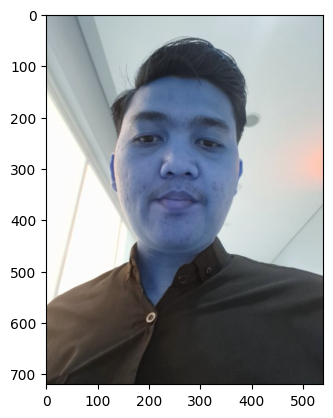

In [25]:
plt.imshow(cv2.imread(img_path))

In [26]:
att_included = ["pred_age","pred_gender"]

### Get Database Info

In [15]:
selected_keys = ['label', 'method', 'processed_path', 'pred_age', 'score_blur_face', 'score_dark', 'score_blur_img', 'score_dfd1-0-0', 'path', 'pred_gender', 'pred_skin_tone']

In [20]:
#data_view = {main_key:{k: d[k] for k in selected_keys if k in d} for main_key,d in data_filtered.items()}
data_view = [{k: d[k] for k in selected_keys if k in d} for d in data_filtered.values()]

In [21]:
import pandas as pd

In [22]:
data_view_df = pd.DataFrame(data_view)

In [25]:
data_view_df.groupby('pred_skin_tone').count()

,label,method,processed_path,pred_age,score_blur_face,score_dark,score_blur_img,score_dfd1-0-0,path,pred_gender
pred_skin_tone,,,,,,,,,,
BA,47,47,47,47,47,47,47,47,47,47
BC,202,202,202,202,202,202,202,202,202,202
BD,1001,1001,1001,1001,1001,1001,1001,1001,1001,1001
BE,14513,14513,14513,14513,14513,14513,14513,14513,14513,14513
BF,7128,7128,7128,7128,7128,7128,7128,7128,7128,7128
BG,11354,11354,11354,11354,11354,11354,11354,11354,11354,11354
BH,510,510,510,510,510,510,510,510,510,510
BI,4103,4103,4103,4103,4103,4103,4103,4103,4103,4103
BJ,340,340,340,340,340,340,340,340,340,340


### Get list of extracted IDs by attribute

In [34]:
'pred_age' in data_filtered[list(data_filtered.keys())[:10][0]]

True

In [35]:
dict_extracted_ids = {"pred_age":[]}
for att_now in dict_extracted_ids.keys():
    for k, v in data_filtered.items():
        if att_now in v:
            dict_extracted_ids[att_now].append(k)

In [36]:
dict_extracted_ids

{'pred_age': ['/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/221657_verify_9da27523-da76-4aeb-9d0e-9e508f39f04d_5c6e2b5c-ffb8-43be-891e-3b33e2820b5e_original.jpg.jpg',
  '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/246505_verify_93f00eaa-0f0d-47f0-a632-d4173082f8d5_1babc1da-fe4c-4433-80ca-2cb1ff70dc92_original.jpg.jpg',
  '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/186513_verify_4ff2e9b4-0edc-4a54-8431-9ea9931dc19e_33e66bd6-0507-4b66-bf11-efa24e7b8cf4_original.jpg.jpg',
  '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/31044_verify_2ef7e08f-78c4-40aa-b38c-255cbaf85fd2_9fae95ca-74be-4bd9-af82-31e01676a147_original.jpg.jpg',
  '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/175216_verify_8c45f7a9-4488-4620-b6f1-f78af7018b73_de477a2e-665d-430d-8d74-9cd29e76f844_original.jpg.jpg',
  '/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live/105243_verify_bcbacb87-524b-4a72-ac60-858f44ddd57f_d3a85990-83ea-47c9-b4bd-4fd4d68d40eb_original.jpg.jpg',